# 요구사항: 
## 쿠폰 만료 케이스 분류 (기간 만료/소진 등), 주행거리(연차별, 차종별 등으로 케이스 분류) 트렌드를 바탕으로 향후 CR 예측
도메인 지식 - CR 종류:
- FMS (Free Maintenance Service): 신차 구매 후 최초 3년 또는 주행거리 30,000km까지 제공되는 무상 점검 및 엔진오일/필터 교환 서비스
- SMS (Smart Maintenance Service): FMS 만료 후에도 관리할 수 있도록 구성된 정기 점검 및 소모품 교환 유상 패키지. 보통 엔진오일 교환 3회 및 정기점검으로 구성, 개별 수리 시보다 약 15% 저렴
- PMS (Periodic Maintenance Service): 정기 점검 및 유지보수

적용 폰트: ['Malgun Gothic']


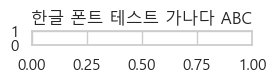

데이터 경로: c:\Project\toyota_project\toyota_project\louis\data\hnd_svc


In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ─────────────────────────────────────────────────────
# sns.set_theme() 이 rcParams를 초기화하므로, set_theme() 이후에 폰트를 덮어써야 함
sns.set_theme(style='whitegrid', palette='muted')

_FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
if os.path.exists(_FONT_PATH):
    fm.fontManager.addfont(_FONT_PATH)
    mpl.rcParams['font.family'] = 'Malgun Gothic'
else:
    # Malgun Gothic 없으면 시스템에서 한글 폰트 탐색
    _candidates = [f.name for f in fm.fontManager.ttflist
                   if any(k in f.name for k in ('Gothic', 'Gulim', 'Dotum', 'Batang'))]
    if _candidates:
        mpl.rcParams['font.family'] = _candidates[0]

mpl.rcParams['axes.unicode_minus'] = False

print(f"적용 폰트: {mpl.rcParams['font.family']}")

# ── 테스트 플롯 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3, 1))
ax.set_title('한글 폰트 테스트 가나다 ABC')
plt.tight_layout(); plt.show(); plt.close()

# ── 경로 & 파라미터 ────────────────────────────────────────────────────
DATA_DIR   = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'data', 'hnd_svc')
RESULT_DIR = os.path.join(DATA_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

# FMS 코드 매핑 — Karete 확인: 10K(12M)=1차, 20K(24M)=2차 ... 50K(60M)=5차
FMS_STANDARD_CODES = {str(10000000 + i): f'FMS_{i}차' for i in range(1, 6)}
FMS_EXTENDED_CODES = {str(10000000 + i): f'PMS_{i-5}차' for i in range(6, 12)}
FMS_SMS_CODES      = {str(10000000 + i): f'SMS_{i-11}차' for i in range(12, 24)}
FMS_ALL_MAP        = {**FMS_STANDARD_CODES, **FMS_EXTENDED_CODES, **FMS_SMS_CODES}

FMS_TOTAL = 5  # 표준 FMS 쿠폰 총 수 (실제 마스터 확인 후 조정)

print(f"데이터 경로: {os.path.abspath(DATA_DIR)}")

## 데이터 로드

In [2]:
def load_pq(filename, required=True):
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f"  ✓ {filename:45s}  {df.shape[0]:>10,} × {df.shape[1]:>3} cols")
        return df
    elif required:
        raise FileNotFoundError(f"{filename} 없음 → 02_manage_storage.ipynb 먼저 실행")
    else:
        print(f"  - {filename:45s}  (미존재, 건너뜀)")
        return None

print("=== Agora (TMKR_L) ===")
agora_propo      = load_pq('agora_svc_propo.parquet')
agora_propo_part = load_pq('agora_svc_propo_part.parquet')
agora_vehic      = load_pq('agora_co_vehic.parquet')
agora_contract   = load_pq('agora_om_contract.parquet')
agora_svc_cr     = load_pq('agora_l_svc_cr.parquet')
agora_cr_vehic   = load_pq('agora_svc_cr_vehic.parquet')

print("\n=== BP/KTWS (KPI_L) ===")
bp_propo    = load_pq('bpktws_svc_propo.parquet')
bp_vehic    = load_pq('bpktws_co_vehic.parquet')
bp_contract = load_pq('bpktws_om_contract.parquet')

print("\n=== Karete ===")
karete_fct      = load_pq('karete_fct_svc_repair.parquet')
karete_propo    = load_pq('karete_svc_propo.parquet',   required=False)
karete_vehic    = load_pq('karete_co_vehic.parquet',    required=False)
karete_contract = load_pq('karete_om_contract.parquet', required=False)

=== Agora (TMKR_L) ===
  ✓ agora_svc_propo.parquet                           715,582 ×  12 cols
  ✓ agora_svc_propo_part.parquet                    2,550,629 ×   8 cols
  ✓ agora_co_vehic.parquet                            227,613 ×  10 cols
  ✓ agora_om_contract.parquet                         231,924 ×   8 cols
  ✓ agora_l_svc_cr.parquet                                165 ×  41 cols
  ✓ agora_svc_cr_vehic.parquet                        264,563 ×  10 cols

=== BP/KTWS (KPI_L) ===
  ✓ bpktws_svc_propo.parquet                          775,020 ×  12 cols
  ✓ bpktws_co_vehic.parquet                           227,613 ×  10 cols
  ✓ bpktws_om_contract.parquet                        231,924 ×   8 cols

=== Karete ===
  ✓ karete_fct_svc_repair.parquet                     571,275 ×  16 cols
  ✓ karete_svc_propo.parquet                        5,072,378 ×  14 cols
  ✓ karete_co_vehic.parquet                           357,365 ×  11 cols
  ✓ karete_om_contract.parquet                        384,69

## 데이터 전처리

### 다른 엔드포인트에 같은 컬럼명 존재. 통일 전 데이터가 같은지 확인

1. 엔드포인트별 데이터 그룹화 -> 대소문자/공백 정리 -> 전체 컬럼 수집 

In [3]:
import pandas as pd
from IPython.display import display

# =========================
# 1. 데이터프레임 그룹 정의
# =========================

groups = {
    "Agora": {
        "agora_svc_propo": agora_propo,
        "agora_svc_propo_part": agora_propo_part,
        "agora_co_vehic": agora_vehic,
        "agora_om_contract": agora_contract,
        "agora_l_svc_cr": agora_svc_cr,
        "agora_svc_cr_vehic": agora_cr_vehic,
    },
    "BP/KTWS": {
        "bpktws_svc_propo": bp_propo,
        "bpktws_co_vehic": bp_vehic,
        "bpktws_om_contract": bp_contract,
    },
    "Karete": {
        "karete_fct_svc_repair": karete_fct,
        "karete_svc_propo": karete_propo,
        "karete_co_vehic": karete_vehic,
        "karete_om_contract": karete_contract,
    }
}

# None인 optional 데이터프레임은 제외
groups = {
    group_name: {
        table_name: df
        for table_name, df in tables.items()
        if df is not None
    }
    for group_name, tables in groups.items()
}


# =========================
# 2. 컬럼명 정규화 함수
# =========================

def normalize_col(col):
    """
    대소문자 구분 없이 비교하기 위한 컬럼명 정규화
    - 앞뒤 공백 제거
    - 대소문자 무시
    """
    return str(col).strip().casefold()


# =========================
# 3. 전체 컬럼 목록 수집
# =========================

records = []

for group_name, tables in groups.items():
    for table_name, df in tables.items():
        for col in df.columns:
            records.append({
                "group": group_name,
                "table": table_name,
                "column_original": col,
                "column_norm": normalize_col(col)
            })

col_df = pd.DataFrame(records).drop_duplicates()

print("전체 컬럼 출현 정보")
display(col_df.head())
print(f"총 컬럼 출현 수: {len(col_df):,}")
print(f"정규화 기준 unique 컬럼 수: {col_df['column_norm'].nunique():,}")

전체 컬럼 출현 정보


,group,table,column_original,column_norm
0,Agora,agora_svc_propo,shop_cd,shop_cd
1,Agora,agora_svc_propo,propo_dt,propo_dt
2,Agora,agora_svc_propo,propo_seq,propo_seq
3,Agora,agora_svc_propo,vin,vin
4,Agora,agora_svc_propo,svc_model_cd,svc_model_cd


총 컬럼 출현 수: 170
정규화 기준 unique 컬럼 수: 107


2. 그룹별 공통 컬럼 확인

In [ ]:
summary = (
    col_df
    .groupby("column_norm")
    .agg(
        group_count=("group", "nunique"),
        groups=("group", lambda x: ", ".join(sorted(set(x)))),
        table_count=("table", "nunique"),
        tables=("table", lambda x: ", ".join(sorted(set(x)))),
        original_columns=("column_original", lambda x: ", ".join(sorted(map(str, set(x)))))
    )
    .reset_index()
    .sort_values(["group_count", "table_count", "column_norm"], ascending=[False, False, True])
)

display(summary)

,column_norm,group_count,groups,table_count,tables,original_columns
104,vin,3,"Agora, BP/KTWS, Karete",11,"agora_co_vehic, agora_om_contract, agora_svc_c...","VIN, vin"
41,odometer,3,"Agora, BP/KTWS, Karete",6,"agora_co_vehic, agora_svc_propo, bpktws_co_veh...","ODOMETER, odometer"
47,propo_seq,3,"Agora, BP/KTWS, Karete",5,"agora_svc_cr_vehic, agora_svc_propo, agora_svc...","PROPO_SEQ, propo_seq"
64,sales_type,3,"Agora, BP/KTWS, Karete",5,"agora_co_vehic, agora_om_contract, bpktws_co_v...","SALES_TYPE, sales_type"
2,base_odometer,3,"Agora, BP/KTWS, Karete",4,"agora_co_vehic, bpktws_co_vehic, karete_co_veh...","BASE_ODOMETER, base_odometer"
...,...,...,...,...,...,...
99,vehicle_model,1,Karete,1,karete_fct_svc_repair,VEHICLE_MODEL
100,vehicle_model_code,1,Karete,1,karete_co_vehic,VEHICLE_MODEL_CODE
102,vehicle_service_model_code,1,Karete,1,karete_fct_svc_repair,VEHICLE_SERVICE_MODEL_CODE
103,vehicle_variant_name,1,Karete,1,karete_co_vehic,VEHICLE_VARIANT_NAME


3. 세 그룹에 모두 존재

In [12]:
all_group_common_cols = summary[summary["group_count"] == len(groups)]

print(f"세 그룹 모두에 존재하는 컬럼 수: {len(all_group_common_cols):,}")
display(all_group_common_cols)

세 그룹 모두에 존재하는 컬럼 수: 7


,column_norm,group_count,groups,table_count,tables,original_columns
104,vin,3,"Agora, BP/KTWS, Karete",11,"agora_co_vehic, agora_om_contract, agora_svc_c...","VIN, vin"
41,odometer,3,"Agora, BP/KTWS, Karete",6,"agora_co_vehic, agora_svc_propo, bpktws_co_veh...","ODOMETER, odometer"
47,propo_seq,3,"Agora, BP/KTWS, Karete",5,"agora_svc_cr_vehic, agora_svc_propo, agora_svc...","PROPO_SEQ, propo_seq"
64,sales_type,3,"Agora, BP/KTWS, Karete",5,"agora_co_vehic, agora_om_contract, bpktws_co_v...","SALES_TYPE, sales_type"
2,base_odometer,3,"Agora, BP/KTWS, Karete",4,"agora_co_vehic, bpktws_co_vehic, karete_co_veh...","BASE_ODOMETER, base_odometer"
26,first_owner_yn,3,"Agora, BP/KTWS, Karete",3,"agora_co_vehic, bpktws_co_vehic, karete_co_vehic","FIRST_OWNER_YN, first_owner_yn"
37,model_year,3,"Agora, BP/KTWS, Karete",3,"agora_co_vehic, bpktws_co_vehic, karete_om_con...","MODEL_YEAR, model_year"


4. 두 그룹에서 존재

In [13]:
shared_cols = summary[summary["group_count"] >= 2]

print(f"두 그룹 이상에서 겹치는 컬럼 수: {len(shared_cols):,}")
display(shared_cols)

두 그룹 이상에서 겹치는 컬럼 수: 24


,column_norm,group_count,groups,table_count,tables,original_columns
104,vin,3,"Agora, BP/KTWS, Karete",11,"agora_co_vehic, agora_om_contract, agora_svc_c...","VIN, vin"
41,odometer,3,"Agora, BP/KTWS, Karete",6,"agora_co_vehic, agora_svc_propo, bpktws_co_veh...","ODOMETER, odometer"
47,propo_seq,3,"Agora, BP/KTWS, Karete",5,"agora_svc_cr_vehic, agora_svc_propo, agora_svc...","PROPO_SEQ, propo_seq"
64,sales_type,3,"Agora, BP/KTWS, Karete",5,"agora_co_vehic, agora_om_contract, bpktws_co_v...","SALES_TYPE, sales_type"
2,base_odometer,3,"Agora, BP/KTWS, Karete",4,"agora_co_vehic, bpktws_co_vehic, karete_co_veh...","BASE_ODOMETER, base_odometer"
26,first_owner_yn,3,"Agora, BP/KTWS, Karete",3,"agora_co_vehic, bpktws_co_vehic, karete_co_vehic","FIRST_OWNER_YN, first_owner_yn"
37,model_year,3,"Agora, BP/KTWS, Karete",3,"agora_co_vehic, bpktws_co_vehic, karete_om_con...","MODEL_YEAR, model_year"
34,model_cd,2,"Agora, BP/KTWS",4,"agora_co_vehic, agora_om_contract, bpktws_co_v...",model_cd
46,propo_dt,2,"Agora, BP/KTWS",4,"agora_svc_cr_vehic, agora_svc_propo, agora_svc...","PROPO_DT, propo_dt"
78,svc_model_cd,2,"Agora, BP/KTWS",4,"agora_co_vehic, agora_svc_propo, bpktws_co_veh...","SVC_MODEL_CD, svc_model_cd"


5. 그룹 페어 공통 컬럼 확인

In [14]:
group_col_sets = {
    group_name: set(
        col_df.loc[col_df["group"] == group_name, "column_norm"]
    )
    for group_name in groups.keys()
}

pair_results = []

group_names = list(groups.keys())

for i in range(len(group_names)):
    for j in range(i + 1, len(group_names)):
        g1 = group_names[i]
        g2 = group_names[j]
        
        common = sorted(group_col_sets[g1] & group_col_sets[g2])
        
        for col_norm in common:
            original_cols = (
                col_df[col_df["column_norm"] == col_norm]
                .groupby("group")["column_original"]
                .apply(lambda x: ", ".join(sorted(map(str, set(x)))))
                .to_dict()
            )
            
            pair_results.append({
                "group_1": g1,
                "group_2": g2,
                "column_norm": col_norm,
                f"{g1}_original": original_cols.get(g1, ""),
                f"{g2}_original": original_cols.get(g2, ""),
            })

pair_common_df = pd.DataFrame(pair_results)

print("그룹 쌍별 공통 컬럼")
display(pair_common_df)

그룹 쌍별 공통 컬럼


,group_1,group_2,column_norm,Agora_original,BP/KTWS_original,Karete_original
0,Agora,BP/KTWS,base_odometer,base_odometer,base_odometer,NaN
1,Agora,BP/KTWS,contract_no,contract_no,contract_no,NaN
2,Agora,BP/KTWS,contract_stat_cd,contract_stat_cd,contract_stat_cd,NaN
3,Agora,BP/KTWS,delivery_actual_dt,delivery_actual_dt,delivery_actual_dt,NaN
4,Agora,BP/KTWS,delivery_dt,delivery_dt,delivery_dt,NaN
5,Agora,BP/KTWS,first_owner_yn,first_owner_yn,first_owner_yn,NaN
6,Agora,BP/KTWS,last_retail_sales_dt,last_retail_sales_dt,last_retail_sales_dt,NaN
7,Agora,BP/KTWS,model_cd,model_cd,model_cd,NaN
8,Agora,BP/KTWS,model_year,model_year,model_year,NaN
9,Agora,BP/KTWS,my_cd,my_cd,my_cd,NaN


6. 테이블 출처 확인

In [15]:
detail = (
    col_df
    .sort_values(["column_norm", "group", "table"])
    .reset_index(drop=True)
)

display(detail)

,group,table,column_original,column_norm
0,Agora,agora_l_svc_cr,APPLY_END_DATE,apply_end_date
1,Agora,agora_l_svc_cr,APPLY_ST_DATE,apply_st_date
2,Agora,agora_co_vehic,base_odometer,base_odometer
3,BP/KTWS,bpktws_co_vehic,base_odometer,base_odometer
4,Karete,karete_co_vehic,BASE_ODOMETER,base_odometer
...,...,...,...,...
165,Karete,karete_om_contract,VIN,vin
166,Karete,karete_svc_propo,VIN,vin
167,Karete,karete_fct_svc_repair,WARRANTY_AMOUNT,warranty_amount
168,Agora,agora_svc_propo,work_close_yn,work_close_yn


7. csv로 저장

In [ ]:
# =========================
# 9. 결과 저장
# =========================

summary.to_csv("column_compare_summary.csv", index=False, encoding="utf-8-sig")
all_group_common_cols.to_csv("column_common_all_groups.csv", index=False, encoding="utf-8-sig")
shared_cols.to_csv("column_shared_two_or_more_groups.csv", index=False, encoding="utf-8-sig")
pair_common_df.to_csv("column_pair_common.csv", index=False, encoding="utf-8-sig")
detail.to_csv("column_compare_detail.cㄴsv", index=False, encoding="utf-8-sig")

print("저장 완료")

저장 완료


## 공통 컬럼 의미 비교 분석

컬럼명이 같더라도 다른 엔드포인트(Agora / BP/KTWS / Karete)에서 다른 의미로 쓰일 수 있음.  
아래에서 dtype, 고유값 수, 상위 값, 값 집합 유사도(Jaccard)를 비교해 **같은 의미인지 판정**함.

**판정 기준**
- 범주형 / ID: Jaccard ≥ 50% → `같은 의미`, 10~50% → `추가 확인 필요`, < 10% → `다른 의미`
- 수치형: dtype 일치 + 값 범위 중첩 여부로 판단 (Jaccard는 참고용)

In [17]:
import itertools

MAX_VC_ROWS  = 300_000   # value_counts 계산용 샘플 크기
MAX_SET_VALS = 100_000   # Jaccard용 value_set 최대 원소 수

def collect_col_stats(col_norm):
    """정규화 컬럼명에 대해 그룹별 통계를 수집"""
    entries = col_df[col_df['column_norm'] == col_norm]
    result = {}

    for group_name in entries['group'].unique():
        g_entries = entries[entries['group'] == group_name]
        dtypes, uniq_vals = [], set()
        total_n = null_n = 0
        vc_parts = []

        for _, r in g_entries.iterrows():
            s = groups[group_name][r['table']][r['column_original']]
            dtypes.append(str(s.dtype))
            uniq_vals.update(s.dropna().unique().tolist())
            total_n += len(s)
            null_n  += int(s.isna().sum())
            samp = s.sample(min(len(s), MAX_VC_ROWS), random_state=42) if len(s) > MAX_VC_ROWS else s
            vc_parts.append(samp)

        combined = pd.concat(vc_parts, ignore_index=True)
        top5     = combined.value_counts().head(5)

        # Jaccard용 값 집합 (최대 MAX_SET_VALS개, 문자열 변환)
        val_list = list(uniq_vals)
        if len(val_list) > MAX_SET_VALS:
            val_list = val_list[:MAX_SET_VALS]

        dropped = combined.dropna()
        result[group_name] = {
            'dtype'     : ' / '.join(sorted(set(dtypes))),
            'is_numeric': combined.dtype.kind in ('i', 'u', 'f'),
            'total_rows': total_n,
            'null_pct'  : null_n / total_n * 100 if total_n else 0,
            'nunique'   : len(uniq_vals),
            'top5'      : top5,
            'value_set' : frozenset(str(v) for v in val_list),
            'tables'    : g_entries['table'].tolist(),
            'min_val'   : dropped.min() if len(dropped) else None,
            'max_val'   : dropped.max() if len(dropped) else None,
        }

    return result


print("공통 컬럼 통계 수집 중...")
col_stats_all = {}
for col_norm in shared_cols['column_norm']:
    print(f"  ▶ {col_norm}", end=" ... ", flush=True)
    col_stats_all[col_norm] = collect_col_stats(col_norm)
    print("완료")
print(f"\n✓ 총 {len(col_stats_all)}개 공통 컬럼 분석 완료")

공통 컬럼 통계 수집 중...
  ▶ vin ... 완료
  ▶ odometer ... 완료
  ▶ propo_seq ... 완료
  ▶ sales_type ... 완료
  ▶ base_odometer ... 완료
  ▶ first_owner_yn ... 완료
  ▶ model_year ... 완료
  ▶ model_cd ... 완료
  ▶ propo_dt ... 완료
  ▶ svc_model_cd ... 완료
  ▶ shop_cd ... 완료
  ▶ stat_cd ... 완료
  ▶ contract_no ... 완료
  ▶ contract_stat_cd ... 완료
  ▶ delivery_actual_dt ... 완료
  ▶ delivery_dt ... 완료
  ▶ last_retail_sales_dt ... 완료
  ▶ my_cd ... 완료
  ▶ prev_odometer ... 완료
  ▶ svc_type_cd ... 완료
  ▶ svc_type_fms_cd ... 완료
  ▶ variant_nm ... 완료
  ▶ vehic_base_odometer ... 완료
  ▶ work_close_yn ... 완료

✓ 총 24개 공통 컬럼 분석 완료


In [18]:
def jaccard(set_a, set_b):
    if not set_a or not set_b:
        return None
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union else 0.0


for col_norm, stats_by_group in col_stats_all.items():
    group_list = list(stats_by_group.keys())

    print(f"\n{'━' * 72}")
    print(f"  컬럼: [{col_norm}]   출현 그룹: {', '.join(group_list)}")
    print(f"{'━' * 72}")

    # 그룹별 기본 통계 테이블
    rows = []
    for gname, s in stats_by_group.items():
        top5_str = ' | '.join(str(v) for v in s['top5'].index.tolist())
        rows.append({
            'group'       : gname,
            'tables'      : ', '.join(s['tables']),
            'dtype'       : s['dtype'],
            'total_rows'  : f"{s['total_rows']:,}",
            'nunique'     : f"{s['nunique']:,}",
            'null%'       : f"{s['null_pct']:.1f}%",
            'min'         : str(s['min_val'])[:25] if s['min_val'] is not None else '-',
            'max'         : str(s['max_val'])[:25] if s['max_val'] is not None else '-',
            'top5 values' : top5_str[:90],
        })
    display(pd.DataFrame(rows).set_index('group'))

    # dtype 일치 여부
    dtypes_set = set(s['dtype'] for s in stats_by_group.values())
    dtype_label = "✓ 일치" if len(dtypes_set) == 1 else f"✗ 불일치 ({' / '.join(sorted(dtypes_set))})"
    print(f"  dtype 비교: {dtype_label}")

    # 페어별 Jaccard
    if len(group_list) >= 2:
        print("  값 집합 유사도 (Jaccard):")
        for g1, g2 in itertools.combinations(group_list, 2):
            j = jaccard(stats_by_group[g1]['value_set'], stats_by_group[g2]['value_set'])
            if j is not None:
                filled = int(j * 20)
                bar = '█' * filled + '░' * (20 - filled)
                print(f"    {g1:10s} ↔ {g2:10s}: [{bar}] {j:.1%}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  컬럼: [vin]   출현 그룹: Agora, BP/KTWS, Karete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,tables,dtype,total_rows,nunique,null%,min,max,top5 values
group,,,,,,,,
Agora,"agora_svc_propo, agora_co_vehic, agora_om_cont...",str,"1,439,682","227,696",3.3%,ZVW30 51755158,qnc20000412,JTHBW1GG9E2045867 | JTHBJ46G892321317 | JTHBW1...
BP/KTWS,"bpktws_svc_propo, bpktws_co_vehic, bpktws_om_c...",str,"1,234,557","227,625",3.9%,ZVW30 51755158,qnc20000412,JTHBW1GG1H2136507 | JTHBW1GG9E2045867 | JTJBJR...
Karete,"karete_fct_svc_repair, karete_svc_propo, karet...",str,"6,385,709","337,972",0.0%,,qnc20000412,| WONJU111111111111 | ABCDEFGHIJK | SUWONSERV...


  dtype 비교: ✓ 일치
  값 집합 유사도 (Jaccard):
    Agora      ↔ BP/KTWS   : [███████████████████░] 99.8%
    Agora      ↔ Karete    : [██████░░░░░░░░░░░░░░] 30.6%
    BP/KTWS    ↔ Karete    : [██████░░░░░░░░░░░░░░] 30.6%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  컬럼: [odometer]   출현 그룹: Agora, BP/KTWS, Karete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,tables,dtype,total_rows,nunique,null%,min,max,top5 values
group,,,,,,,,
Agora,"agora_svc_propo, agora_co_vehic",int64,"943,195","190,190",0.0%,-1,2412361,5 | 100 | 1 | 4 | 2
BP/KTWS,"bpktws_svc_propo, bpktws_co_vehic",int64,"1,002,633","191,319",0.0%,-1,2412361,5 | 100 | 1 | 4 | 2
Karete,"karete_svc_propo, karete_co_vehic",float64,"5,429,743","309,994",0.1%,-1.0,1447712.0,0.0 | 1.0 | 5.0 | 4.0 | 3.0


  dtype 비교: ✗ 불일치 (float64 / int64)
  값 집합 유사도 (Jaccard):
    Agora      ↔ BP/KTWS   : [███████████████████░] 99.5%
    Agora      ↔ Karete    : [░░░░░░░░░░░░░░░░░░░░] 0.0%
    BP/KTWS    ↔ Karete    : [░░░░░░░░░░░░░░░░░░░░] 0.0%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  컬럼: [propo_seq]   출현 그룹: Agora, BP/KTWS, Karete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


...

  dtype 비교: ✓ 일치
  값 집합 유사도 (Jaccard):
    Agora      ↔ BP/KTWS   : [████████████████████] 100.0%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  컬럼: [vehic_base_odometer]   출현 그룹: Agora, BP/KTWS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,tables,dtype,total_rows,nunique,null%,min,max,top5 values
group,,,,,,,,
Agora,agora_svc_propo,int64,"715,582",12,0.0%,0,109998,0 | 1 | 48102 | 4308 | 11366
BP/KTWS,bpktws_svc_propo,int64,"775,020",13,0.0%,0,109998,0 | 4308 | 1 | 48102 | 2395


  dtype 비교: ✓ 일치
  값 집합 유사도 (Jaccard):
    Agora      ↔ BP/KTWS   : [██████████████████░░] 92.3%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  컬럼: [work_close_yn]   출현 그룹: Agora, BP/KTWS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,tables,dtype,total_rows,nunique,null%,min,max,top5 values
group,,,,,,,,
Agora,agora_svc_propo,str,"715,582",1,3.2%,N,N,N
BP/KTWS,bpktws_svc_propo,str,"775,020",1,2.9%,N,N,N


  dtype 비교: ✓ 일치
  값 집합 유사도 (Jaccard):
    Agora      ↔ BP/KTWS   : [████████████████████] 100.0%


In [19]:
verdict_rows = []

for col_norm, stats_by_group in col_stats_all.items():
    group_list = list(stats_by_group.keys())
    dtypes     = sorted({s['dtype'] for s in stats_by_group.values()})
    dtype_match = len(dtypes) == 1
    is_numeric  = stats_by_group[group_list[0]]['is_numeric']

    j_scores = [
        j for g1, g2 in itertools.combinations(group_list, 2)
        if (j := jaccard(stats_by_group[g1]['value_set'], stats_by_group[g2]['value_set'])) is not None
    ]
    avg_j = sum(j_scores) / len(j_scores) if j_scores else None

    # 판정 로직
    if avg_j is None:
        verdict = "⚠️ 확인불가"
    elif not dtype_match:
        verdict = "❌ 다른 의미 (dtype 불일치)"
    elif is_numeric:
        # 수치형은 Jaccard가 과소평가되므로 dtype 일치만으로 긍정 판정
        verdict = "✅ 같은 의미 (수치형, dtype 일치)" if avg_j >= 0.001 else "⚠️ 추가 확인 필요"
    else:
        if avg_j >= 0.5:
            verdict = "✅ 같은 의미"
        elif avg_j >= 0.1:
            verdict = "⚠️ 추가 확인 필요"
        else:
            verdict = "❌ 다른 의미"

    verdict_rows.append({
        'column_norm' : col_norm,
        'groups'      : ', '.join(group_list),
        'dtype_match' : '✓' if dtype_match else '✗',
        'dtypes'      : ' / '.join(dtypes),
        'col_type'    : '수치형' if is_numeric else '범주/문자형',
        'avg_jaccard' : f"{avg_j:.1%}" if avg_j is not None else "N/A",
        'verdict'     : verdict,
    })

verdict_df = (
    pd.DataFrame(verdict_rows)
    .sort_values('avg_jaccard', ascending=False)
    .reset_index(drop=True)
)

print("━" * 65)
print("  공통 컬럼 의미 동일성 판정 요약")
print("━" * 65)
display(verdict_df.set_index('column_norm'))

verdict_df.to_csv("column_meaning_verdict.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: column_meaning_verdict.csv")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  공통 컬럼 의미 동일성 판정 요약
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,groups,dtype_match,dtypes,col_type,avg_jaccard,verdict
column_norm,,,,,,
prev_odometer,"Agora, BP/KTWS",✓,float64,수치형,97.4%,"✅ 같은 의미 (수치형, dtype 일치)"
vehic_base_odometer,"Agora, BP/KTWS",✓,int64,수치형,92.3%,"✅ 같은 의미 (수치형, dtype 일치)"
shop_cd,"Agora, BP/KTWS",✓,str,범주/문자형,90.5%,✅ 같은 의미
propo_dt,"Agora, BP/KTWS",✓,str,범주/문자형,88.4%,✅ 같은 의미
model_year,"Agora, BP/KTWS, Karete",✓,str,범주/문자형,80.4%,✅ 같은 의미
vin,"Agora, BP/KTWS, Karete",✓,str,범주/문자형,53.7%,✅ 같은 의미
sales_type,"Agora, BP/KTWS, Karete",✓,str,범주/문자형,51.9%,✅ 같은 의미
base_odometer,"Agora, BP/KTWS, Karete",✗,float64 / int64,수치형,33.3%,❌ 다른 의미 (dtype 불일치)
odometer,"Agora, BP/KTWS, Karete",✗,float64 / int64,수치형,33.2%,❌ 다른 의미 (dtype 불일치)



저장 완료: column_meaning_verdict.csv
